# Project Master Runner

This is the central entry point for the **Ecommerce Sentiment Analysis** project. It imports the logic from internal notebooks and executes the analysis pipeline.

In [4]:
# Load the DataExploration class from the notebooks folder
%run notebooks/DataExploration.ipynb

# Define the dataset path
data_path = 'Ecommerce_dataset/train_data.csv'

# Instantiate and run the analysis
eda = DataExploration(data_path)
eda.get_summary()
eda.get_sentiment_distribution()
eda.remove_nulls(columns=['reviews.text', 'sentiment'])



Dataset loaded successfully with 4000 rows and 8 columns.

DATASET SUMMARY

--- First 5 rows ---
                                                name   brand  \
0  All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi...  Amazon   
1        Amazon - Echo Plus w/ Built-In Hub - Silver  Amazon   
2  Amazon Echo Show Alexa-enabled Bluetooth Speak...  Amazon   
3  Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...  Amazon   
4  Brand New Amazon Kindle Fire 16gb 7" Ips Displ...  Amazon   

                                          categories  \
0  Electronics,iPad & Tablets,All Tablets,Fire Ta...   
1  Amazon Echo,Smart Home,Networking,Home & Tools...   
2  Amazon Echo,Virtual Assistant Speakers,Electro...   
3  eBook Readers,Fire Tablets,Electronics Feature...   
4  Computers/Tablets & Networking,Tablets & eBook...   

             primaryCategories              reviews.date  \
0                  Electronics  2016-12-26T00:00:00.000Z   
1         Electronics,Hardware  2018-01-17T00:00:00.000Z   
2

In [ ]:
# ══════════════════════════════════════════════════════
# LOAD PRE-TRAINED WEIGHTS  (run this instead of training cells)
# ══════════════════════════════════════════════════════
import sys, os
sys.path.insert(0, "src")
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf

from bert_classifier    import BertSentimentClassifier
from deberta_classifier import DebertaSentimentClassifier

# ── Load BERT ──────────────────────────────────────────
bert_clf = BertSentimentClassifier()
bert_clf.load()                          # loads models/bert/weights.h5
model     = bert_clf.model
tokenizer = bert_clf.tokenizer

# ── Load DeBERTa ───────────────────────────────────────
deberta_clf = DebertaSentimentClassifier()
deberta_clf.load()                       # loads models/deberta/weights.h5
deberta_model     = deberta_clf.model
deberta_tokenizer = deberta_clf.tokenizer

print("Both models loaded and ready for evaluation!")


#### So the data have no null values

In [5]:
#Check the split of the training data
positive = (eda.df["sentiment"] == "Positive").sum()
neutral = (eda.df["sentiment"] == "Neutral").sum()
negative = (eda.df["sentiment"] == "Negative").sum()

print(f"Positive: {positive}")
print(f"Neutral: {neutral}")
print(f"Negative: {negative}")


Positive: 3749
Neutral: 158
Negative: 93


In [ ]:
import sys, os
sys.path.insert(0, "src")
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from bert_classifier import BertSentimentClassifier

# ── Config ─────────────────────────────────────────────────────────────────
EPOCHS     = 5
BATCH_SIZE = 32

# GPU
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# ── Data ──────────────────────────────────────────────────────────────────
train_df = pd.read_csv("Ecommerce_dataset/train_data.csv")
train_df.dropna(subset=["reviews.text", "sentiment"], inplace=True)

label_map    = {"Negative": 0, "Neutral": 1, "Positive": 2}
train_labels = train_df["sentiment"].map(label_map).values

cw_array = compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels)
cw_dict  = dict(enumerate(cw_array))
print("Class weights:", {["Negative","Neutral","Positive"][k]: round(v,2) for k,v in cw_dict.items()})

# ── Build & Train ─────────────────────────────────────────────────────────
steps_per_epoch = len(train_labels) // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = total_steps // 10

bert_clf = BertSentimentClassifier()
bert_clf.build(total_steps=total_steps, warmup_steps=warmup_steps)

dataset = BertSentimentClassifier.make_dataset(
    train_df["reviews.text"].tolist(), train_labels.tolist(),
    bert_clf.tokenizer, batch_size=BATCH_SIZE
)

bert_clf.train(dataset, epochs=EPOCHS, class_weight=cw_dict)

# ── Save weights ───────────────────────────────────────────────────────────
bert_clf.save()   # → models/bert/weights.h5
model     = bert_clf.model
tokenizer = bert_clf.tokenizer
print("Done. Weights saved to models/bert/weights.h5")


In [ ]:
# ── BERT Evaluation ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
import tensorflow as tf

CLASS_NAMES = ["Negative", "Neutral", "Positive"]

test_df = pd.read_csv("Ecommerce_dataset/test_data_hidden.csv")
test_df.dropna(subset=["reviews.text", "sentiment"], inplace=True)

# Use the class method from bert_clf
results = bert_clf.evaluate(test_df)
y_true, y_pred = results["y_true"], results["y_pred"]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("BERT-base-uncased — Sentiment Classification", fontsize=14, fontweight="bold")

# Grouped bar chart
x       = np.arange(len(CLASS_NAMES))
width   = 0.25
colors  = ["#4C72B0", "#55A868", "#DD8452"]
per_prec = list(results["per_class_precision"].values())
per_rec  = list(results["per_class_recall"].values())
per_f1   = list(results["per_class_f1"].values())

for vals, label, color, offset in zip(
    [per_prec, per_rec, per_f1],
    ["Precision", "Recall", "F1"],
    colors, [-width, 0, width]
):
    bars = axes[0].bar(x + offset, vals, width, label=label, color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                     f"{h:.2f}", ha="center", va="bottom", fontsize=8)

axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylim(0, 1.15); axes[0].set_title("Per-Class Metrics"); axes[0].legend()
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
axes[0].grid(axis="y", alpha=0.3)

# Confusion matrix
cm  = confusion_matrix(y_true, y_pred)
im  = axes[1].imshow(cm, cmap="Blues")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels([f"Pred\n{c}" for c in CLASS_NAMES])
axes[1].set_yticks(range(3)); axes[1].set_yticklabels([f"Actual {c}" for c in CLASS_NAMES])
plt.colorbar(im, ax=axes[1])
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, cm[i,j], ha="center", va="center", fontsize=13, fontweight="bold",
                     color="white" if cm[i,j] > thresh else "black")

plt.tight_layout()
import os; os.makedirs("reports", exist_ok=True)
plt.savefig("reports/bert_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/bert_results.png")


In [4]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from deberta_classifier import DebertaSentimentClassifier

# ── Config ─────────────────────────────────────────────────────────────────
EPOCHS     = 10
BATCH_SIZE = 16

# GPU
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# ── Data ──────────────────────────────────────────────────────────────────
train_df = pd.read_csv("Ecommerce_dataset/train_data.csv")
train_df.dropna(subset=["reviews.text", "sentiment"], inplace=True)

label_map    = {"Negative": 0, "Neutral": 1, "Positive": 2}
train_labels = train_df["sentiment"].map(label_map).values

cw_array = compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels)
cw_dict  = dict(enumerate(cw_array))
print("Class weights:", {["Negative","Neutral","Positive"][k]: round(v,2) for k,v in cw_dict.items()})

# ── Build & Train ─────────────────────────────────────────────────────────
steps_per_epoch = len(train_labels) // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = total_steps // 10

deberta_clf = DebertaSentimentClassifier()
deberta_clf.build(total_steps=total_steps, warmup_steps=warmup_steps)

db_dataset = DebertaSentimentClassifier.make_dataset(
    train_df["reviews.text"].tolist(), train_labels.tolist(),
    deberta_clf.tokenizer, batch_size=BATCH_SIZE
)

deberta_clf.train(db_dataset, epochs=EPOCHS, class_weight=cw_dict)

# ── Save weights ───────────────────────────────────────────────────────────
deberta_clf.save()   # → models/deberta/weights.h5
deberta_model     = deberta_clf.model
deberta_tokenizer = deberta_clf.tokenizer
print("Done. Weights saved to models/deberta/weights.h5")


125/125 [==============================] - 52s 414ms/step

  Overall Accuracy : 0.9657  (96.58%)

Metrics Table:
                Precision  Recall  F1 Score  Support
Class                                               
Negative           0.8585  0.9785    0.9146       93
Neutral            0.5662  0.9747    0.7163      158
Positive           0.9989  0.9651    0.9817     3749
── Macro ──           NaN     NaN    0.8708     4000
── Weighted ──        NaN     NaN    0.9696     4000



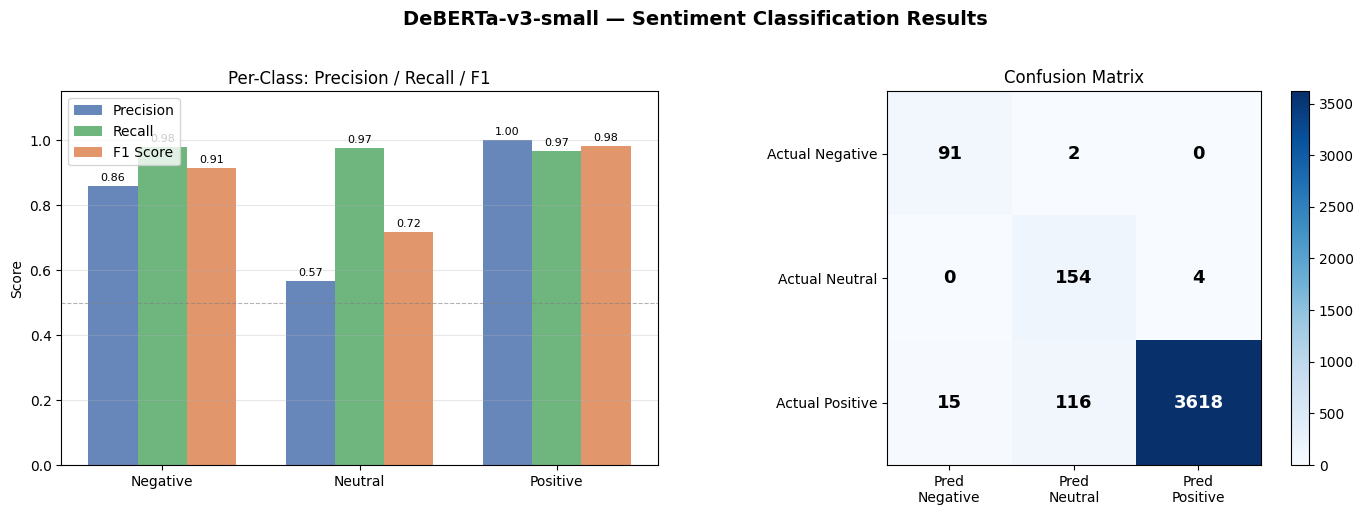

Plot saved to reports/deberta_results.png

Full Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.98      0.91        93
     Neutral       0.57      0.97      0.72       158
    Positive       1.00      0.97      0.98      3749

    accuracy                           0.97      4000
   macro avg       0.81      0.97      0.87      4000
weighted avg       0.98      0.97      0.97      4000



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              precision_score, recall_score)

CLASS_NAMES = ["Negative", "Neutral", "Positive"]

# ── Load Test Data ─────────────────────────────────────────────────────────
test_df = pd.read_csv("Ecommerce_dataset/train_data.csv")
test_df.dropna(subset=["reviews.text", "sentiment"], inplace=True)

label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
y_true    = test_df["sentiment"].map(label_map).values

# ── Tokenise & Predict ────────────────────────────────────────────────────
test_encoded = deberta_tokenizer(
    test_df["reviews.text"].tolist(),
    max_length=248, padding="max_length",
    truncation=True, return_tensors="tf"
)
test_dataset = tf.data.Dataset.from_tensor_slices({
    "input_ids":      test_encoded["input_ids"],
    "attention_mask": test_encoded["attention_mask"]
}).batch(32).prefetch(tf.data.AUTOTUNE)

y_pred_probs = deberta_model.predict(test_dataset)
y_pred       = np.argmax(y_pred_probs, axis=1)

# ── Compute Metrics ───────────────────────────────────────────────────────
acc         = accuracy_score(y_true, y_pred)
macro_f1    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
per_f1      = f1_score(y_true, y_pred, average=None,       zero_division=0)
per_prec    = precision_score(y_true, y_pred, average=None, zero_division=0)
per_rec     = recall_score(y_true, y_pred, average=None,   zero_division=0)

# ── Summary Table ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Class":     CLASS_NAMES + ["── Macro ──", "── Weighted ──"],
    "Precision": list(per_prec) + [None, None],
    "Recall":    list(per_rec)  + [None, None],
    "F1 Score":  list(per_f1)  + [macro_f1, weighted_f1],
    "Support":   [int((y_true == i).sum()) for i in range(3)] + [len(y_true), len(y_true)],
}).set_index("Class")

print(f"\n{'='*55}")
print(f"  Overall Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"{'='*55}")
print("\nMetrics Table:")
print(summary.to_string(float_format=lambda x: f"{x:.4f}" if x is not None else "  ─  "))
print()

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DeBERTa-v3-small — Sentiment Classification Results",
             fontsize=14, fontweight="bold", y=1.02)

# --- Left: Grouped bar chart (Precision / Recall / F1 per class) ----------
x      = np.arange(len(CLASS_NAMES))
width  = 0.25
colors = ["#4C72B0", "#55A868", "#DD8452"]

bars_p = axes[0].bar(x - width, per_prec, width, label="Precision", color=colors[0], alpha=0.85)
bars_r = axes[0].bar(x,          per_rec,  width, label="Recall",    color=colors[1], alpha=0.85)
bars_f = axes[0].bar(x + width,  per_f1,   width, label="F1 Score",  color=colors[2], alpha=0.85)

for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                     f"{h:.2f}", ha="center", va="bottom", fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Score")
axes[0].set_title("Per-Class: Precision / Recall / F1")
axes[0].legend()
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].grid(axis="y", alpha=0.3)

# --- Right: Confusion Matrix heatmap -------------------------------------
cm = confusion_matrix(y_true, y_pred)
im = axes[1].imshow(cm, interpolation="nearest", cmap="Blues")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks(range(len(CLASS_NAMES)))
axes[1].set_yticks(range(len(CLASS_NAMES)))
axes[1].set_xticklabels([f"Pred\n{c}" for c in CLASS_NAMES])
axes[1].set_yticklabels([f"Actual {c}" for c in CLASS_NAMES])
plt.colorbar(im, ax=axes[1])

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black",
                     fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("reports/deberta_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to reports/deberta_results.png")

# ── Full Report ───────────────────────────────────────────────────────────
print("\nFull Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

In [ ]:
# ── BERT vs DeBERTa Head-to-Head ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
import tensorflow as tf

CLASS_NAMES = ["Negative", "Neutral", "Positive"]

test_df = pd.read_csv("Ecommerce_dataset/test_data_hidden.csv")
test_df.dropna(subset=["reviews.text", "sentiment"], inplace=True)

bert_res    = bert_clf.evaluate(test_df)
deberta_res = deberta_clf.evaluate(test_df)

rows = []
for res in [bert_res, deberta_res]:
    rows.append({
        "Model":     res["model"],
        "Accuracy":  f"{res['accuracy']*100:.1f}%",
        "Macro F1":  f"{res['macro_f1']:.3f}",
        "Neg F1":    f"{res['per_class_f1']['Negative']:.3f}",
        "Neu F1":    f"{res['per_class_f1']['Neutral']:.3f}",
        "Pos F1":    f"{res['per_class_f1']['Positive']:.3f}",
    })

print("\n" + "="*60)
print("  BERT vs DeBERTa — Head-to-Head Comparison")
print("="*60)
print(pd.DataFrame(rows).to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 4))
metrics = ["Accuracy", "Macro F1", "Neg F1", "Neu F1", "Pos F1"]
bert_vals    = [bert_res["accuracy"],
                bert_res["macro_f1"],
                bert_res["per_class_f1"]["Negative"],
                bert_res["per_class_f1"]["Neutral"],
                bert_res["per_class_f1"]["Positive"]]
deberta_vals = [deberta_res["accuracy"],
                deberta_res["macro_f1"],
                deberta_res["per_class_f1"]["Negative"],
                deberta_res["per_class_f1"]["Neutral"],
                deberta_res["per_class_f1"]["Positive"]]

x     = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, bert_vals,    width, label="BERT",             color="#4C72B0", alpha=0.85)
ax.bar(x + width/2, deberta_vals, width, label="DeBERTa-v3-small", color="#DD8452", alpha=0.85)
for i, (b, d) in enumerate(zip(bert_vals, deberta_vals)):
    ax.text(i - width/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=8)
    ax.text(i + width/2, d + 0.01, f"{d:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15); ax.legend(); ax.grid(axis="y", alpha=0.3)
ax.set_title("BERT vs DeBERTa — Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/model_comparison.png")
